In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

In [14]:
tickers=["SPY"#US Equities
         ,"IWM"#small caps
         ,"EFA"#developed ex-US
         ,"EEM"#emerging markets
         ,"TLT"#long bonds
         ,"IEF"#intermediate bonds
         ,"GLD"]#gold
prices=yf.download(tickers, start="2015-01-01",auto_adjust=True, progress=False)["Close"].dropna()
prices.head()


Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2015-01-02,30.355045,43.780624,114.080002,83.933128,102.969833,170.589645,94.760468
2015-01-05,29.814812,42.747189,115.800003,84.445236,101.593208,167.508865,96.249039
2015-01-06,29.689545,42.262981,117.120003,85.012550,99.835632,165.931061,97.983185
2015-01-07,30.331566,42.732719,116.430000,84.996773,101.065056,167.998764,97.789627
2015-01-08,30.848310,43.310883,115.940002,84.650124,102.779350,170.979904,96.494591


In [15]:
returns=prices.pct_change().dropna()
returns.head()

Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2015-01-05,-0.017797,-0.023605,0.015077,0.006101,-0.013369,-0.018060,0.015709
2015-01-06,-0.004202,-0.011327,0.011399,0.006718,-0.017300,-0.009419,0.018017
2015-01-07,0.021624,0.011115,-0.005891,-0.000186,0.012314,0.012461,-0.001975
2015-01-08,0.017037,0.013530,-0.004209,-0.004078,0.016962,0.017745,-0.013243
2015-01-09,-0.003299,-0.004839,0.011385,0.004933,-0.009603,-0.008013,0.010953


In [16]:
momentum=prices.pct_change(252).shift(21)
#12 month momentum(252 trading days), skip last 21 days
momentum.tail()

Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2025-12-31,0.292165,0.260139,0.604240,0.067051,0.031864,0.146325,0.007277
2026-01-02,0.290846,0.257582,0.590373,0.063653,0.028563,0.151939,0.000796
2026-01-05,0.289706,0.247680,0.575308,0.061372,0.043290,0.148792,-0.006639
2026-01-06,0.284421,0.247599,0.590248,0.058178,0.052965,0.147575,-0.014361
2026-01-07,0.291438,0.240550,0.584225,0.059002,0.056089,0.149221,-0.010384


In [18]:
#monthly rebalancing dates
monthly_dates=momentum.resample("ME").last().dropna()
monthly_ranks=monthly_dates.rank(axis=1, ascending=False)
monthly_ranks.head()

Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2016-02-29,7.0,4.0,6.0,1.0,5.0,2.0,3.0
2016-03-31,7.0,5.0,3.0,1.0,6.0,4.0,2.0
2016-04-30,7.0,5.0,2.0,1.0,6.0,4.0,3.0
2016-05-31,7.0,6.0,1.0,3.0,5.0,4.0,2.0
2016-06-30,7.0,6.0,4.0,2.0,5.0,3.0,1.0


In [20]:
top_n=3
weights_monthly=monthly_ranks.apply(lambda x :(x<=top_n).astype(int)/top_n,axis=1)

weights_monthly.head()

Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2016-02-29,0.0,0.0,0.000000,0.333333,0.0,0.333333,0.333333
2016-03-31,0.0,0.0,0.333333,0.333333,0.0,0.000000,0.333333
2016-04-30,0.0,0.0,0.333333,0.333333,0.0,0.000000,0.333333
2016-05-31,0.0,0.0,0.333333,0.333333,0.0,0.000000,0.333333
2016-06-30,0.0,0.0,0.000000,0.333333,0.0,0.333333,0.333333


In [25]:
weights_daily=weights_monthly.reindex(returns.index, method="ffill")
valid_start= weights_daily.dropna().index[0]
weights_daily=weights_daily.loc[valid_start:]
returns_aligned =returns.loc[valid_start:]
weights_daily.head()

Ticker,EEM,EFA,GLD,IEF,IWM,SPY,TLT
Date,,,,,,,
2016-02-29,0.0,0.0,0.0,0.333333,0.0,0.333333,0.333333
2016-03-01,0.0,0.0,0.0,0.333333,0.0,0.333333,0.333333
2016-03-02,0.0,0.0,0.0,0.333333,0.0,0.333333,0.333333
2016-03-03,0.0,0.0,0.0,0.333333,0.0,0.333333,0.333333
2016-03-04,0.0,0.0,0.0,0.333333,0.0,0.333333,0.333333


In [26]:
strategy_returns=(weights_daily*returns_aligned).sum(axis=1)
benchmark_returns= returns_aligned.mean(axis=1)

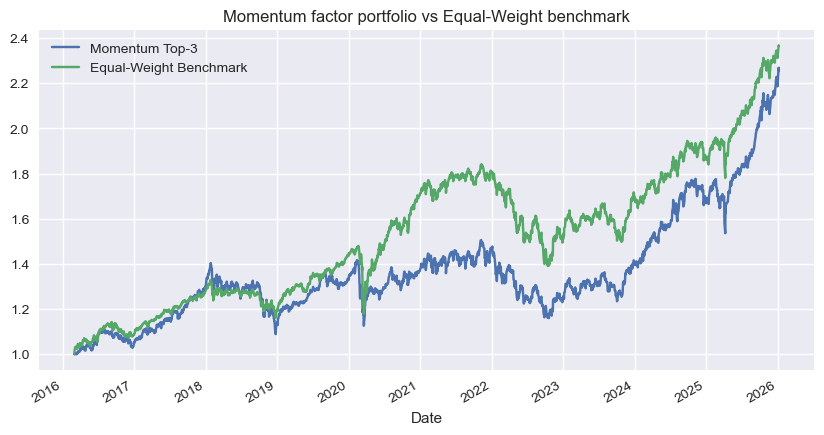

In [27]:
equity=(1+pd.DataFrame({"Momentum Top-3": strategy_returns,"Equal-Weight Benchmark":benchmark_returns})).cumprod()

equity.plot(figsize=(10,5),title="Momentum factor portfolio vs Equal-Weight benchmark")

plt.show()

In [28]:
def perf_stats(r):
    ann_return = (1 + r).prod()**(252/len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    return pd.Series({
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })

stats = pd.DataFrame({
    "Momentum Top-3": perf_stats(strategy_returns),
    "Equal-Weight Benchmark": perf_stats(benchmark_returns)
})

stats


,Momentum Top-3,Equal-Weight Benchmark
Annual Return,0.086200,0.091437
Annual Vol,0.127028,0.109531
Sharpe,0.678587,0.834804
Max Drawdown,-0.229691,-0.244499


In [29]:
# Turnover = sum of absolute weight changes at each rebalance
turnover = weights_monthly.diff().abs().sum(axis=1)

turnover.describe()


count    120.000000
mean       0.372222
std        0.403494
min        0.000000
25%        0.000000
50%        0.333333
75%        0.666667
max        1.333333
dtype: float64

In [36]:
tcost_per_turnover = 0.001  # 10 bps
transaction_costs = turnover * tcost_per_turnover
portfolio_returns_daily = (weights_daily * returns_aligned).sum(axis=1)

In [40]:
portfolio_returns_monthly = (
    1 + portfolio_returns_daily
).resample("ME").prod() - 1

portfolio_returns_monthly_net = (
    portfolio_returns_monthly - transaction_costs
).dropna()

In [41]:
def performance_stats(returns):
    ann_ret = (1 + returns).prod() ** (12 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol
    cum = (1 + returns).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()

    return pd.Series({
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })


In [42]:
performance_stats(portfolio_returns_monthly_net)

Annual Return    0.079979
Annual Vol       0.110368
Sharpe           0.724664
Max Drawdown    -0.201064
dtype: float64

In [43]:
target_vol = 0.10

rolling_vol = (
    portfolio_returns_daily
    .rolling(63)
    .std()
    * np.sqrt(252)
)


In [44]:
scaling = target_vol / rolling_vol
scaling = scaling.clip(upper=2)  # prevent leverage explosion


In [45]:
scaled_returns_daily = portfolio_returns_daily * scaling
scaled_returns_daily = scaled_returns_daily.dropna()


In [46]:
scaled_returns_monthly = (
    1 + scaled_returns_daily
).resample("ME").prod() - 1


In [47]:
scaled_net_returns = (
    scaled_returns_monthly - transaction_costs
).dropna()

performance_stats(scaled_net_returns)


Annual Return    0.084406
Annual Vol       0.103686
Sharpe           0.814056
Max Drawdown    -0.150113
dtype: float64